## 1. Load and Import

## Problem Definition & Implementation

**Task:** Multi-class classification — assign each of LA County's 2,493 census tracts to one of four wildfire risk tiers: Low, Medium, High or Critical.

**Real-world purpose:** Identify which communities are most vulnerable during a wildfire so that emergency managers can pre-position resources, prioritize evacuation orders, and route residents away from high-risk road segments.

**Implementation:** Jupyter notebooks executed in sequence (`feature_engineering.ipynb` → `model_trainning.ipynb` → `visualizations.ipynb`). Outputs are interactive Folium HTML maps and a serialized model (`risk_classifier.pkl`) that can be loaded by downstream routing or dashboard code.

In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
)
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PROC = Path("../data/processed")
MODEL_OUT = Path("../outputs/models")
MODEL_OUT.mkdir(parents=True, exist_ok=True)

TIER_LABELS = {0: "Low", 1: "Medium", 2: "High",3: "Critical"}

## 2. Load Features

In [13]:
tracts = gpd.read_file(DATA_PROC / "features.geojson")

# Drop 25 tracts whose composite risk_score is NaN (originally SVI = -999 sentinel)
tracts = tracts.dropna(subset=["risk_tier"]).reset_index(drop=True)

FEATURES = [
    "dist_fire_station_m",
    "dist_hospital_m",
    "hydrant_density",
    "road_density",
    "pop_density",
    "rpl_theme_1",   # Socioeconomic status percentile
    "rpl_theme_2",   # Household characteristics percentile
    "rpl_theme_3",   # Racial/ethnic minority percentile
    "rpl_theme_4",   # Housing type & transportation percentile
]

X = tracts[FEATURES].copy()
y = tracts["risk_tier"].astype(int)

print(f"Tracts loaded: {len(X)}")
print(f"\nClass distribution:")
print(y.value_counts().sort_index().rename(TIER_LABELS))
X.describe()

Tracts loaded: 2468

Class distribution:
risk_tier
Low         617
Medium      617
High        617
Critical    617
Name: count, dtype: int64


,dist_fire_station_m,dist_hospital_m,hydrant_density,road_density,pop_density,rpl_theme_1,rpl_theme_2,rpl_theme_3,rpl_theme_4
count,2468.000000,2468.000000,2468.000000,2468.000000,2468.000000,2468.000000,2468.000000,2468.000000,2468.000000
mean,1332.640118,2965.065758,31.246253,7214.005462,5335.752373,0.591512,0.519685,0.631909,0.552150
std,1730.354625,2858.131473,38.266509,4146.046024,4619.557250,0.282647,0.286970,0.293497,0.284790
min,21.555438,61.365200,0.000000,0.000000,0.928070,0.000700,0.000000,0.001500,0.000000
25%,792.097725,1406.650781,0.000000,4334.569202,2493.738751,0.356150,0.267825,0.388200,0.316400
50%,1178.012139,2391.665413,0.000000,6716.402321,4181.023135,0.633450,0.554050,0.708700,0.578650
75%,1605.548684,3665.375962,64.612924,9390.936671,6945.452930,0.842125,0.759300,0.897600,0.797425
max,62357.299137,37682.416688,261.360963,32063.184852,51699.896878,0.999900,0.999400,0.994800,1.000000


## 3. Risk Labels — Composite Score (Non-Circular)

Labels come from `feature_engineering.ipynb` via a composite risk score that blends social vulnerability and infrastructure access:

```
risk_score = 0.4 × norm_SVI  +  0.3 × norm_dist_fire_station
           + 0.2 × norm(1/road_density)  +  0.1 × norm(1/hydrant_density)
```

Tiers are assigned via **quantile-based bins** (equal fourths) so each class holds ~1/4 of all tracts, giving balanced training data.

Risk tier distribution (composite score, quantile bins):
risk_tier
Low         617
Medium      617
High        617
Critical    617
Name: count, dtype: int64


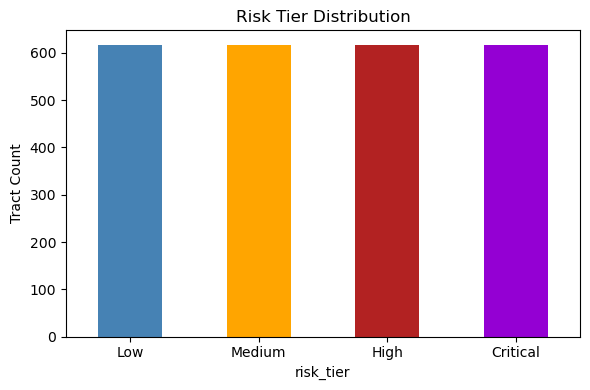

In [14]:
# Labels already loaded from features.geojson — verify distribution
print("Risk tier distribution (composite score, quantile bins):")
print(y.value_counts().sort_index().rename(TIER_LABELS))

y.value_counts().sort_index().rename(TIER_LABELS).plot(
    kind="bar", color=["steelblue", "orange", "firebrick", "darkviolet"],
    figsize=(6, 4), rot=0,
)
plt.title("Risk Tier Distribution")
plt.ylabel("Tract Count")
plt.tight_layout()
plt.show()

## 4. Train/ Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 1974  |  Test: 494


## Model Selection Rationale

**We chose Random Forest?**
- **Mixed-scale features** — distances (meters), density ratios, and normalized SVI scores coexist; tree ensembles require no feature-scale assumptions.
- **Interpretable** — feature importances and SHAP values explain which factors drive high-risk predictions.
- **Class imbalance** — `class_weight="balanced"` up-weights minority classes automatically.
- **Non-linear interactions** — the relationship between infrastructure proximity and composite risk is unlikely to be linear; bagged decision trees capture these interactions naturally.

**We chose GridSearchCV?**  
Exhaustive search over `n_estimators`, `max_depth`, and `min_samples_split` with 5-fold CV ensures we select the best-generalizing hyperparameters rather than hand-tuning.

## 5. Model Training — Random Forest + GridSearchCV

In [16]:
param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_sc, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1 (weighted): {grid_search.best_score_:.3f}")

rf = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 (weighted): 0.910


## 6. Evaluation

**Why recall matters most here:**  
A false negative — predicting *Low*, *Medium*, or *High* when a tract is actually *Critical* risk — means evacuation resources are not pre-positioned and residents may not receive timely evacuation warnings. Missing a critical-risk community is far more dangerous than a false alarm.  
**Recall on the Critical-risk class is therefore the primary safety metric.**

  Accuracy           : 0.899
  F1 (weighted)      : 0.900
  F1 (macro)         : 0.900   ← equal weight per class
  ROC-AUC (OvR macro): 0.991
  High-risk recall   : 0.855
  Critical recall    : 0.911  ← primary safety metric

              precision    recall  f1-score   support

         Low       0.98      0.94      0.96       124
      Medium       0.86      0.89      0.87       123
        High       0.82      0.85      0.84       124
    Critical       0.94      0.91      0.93       123

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



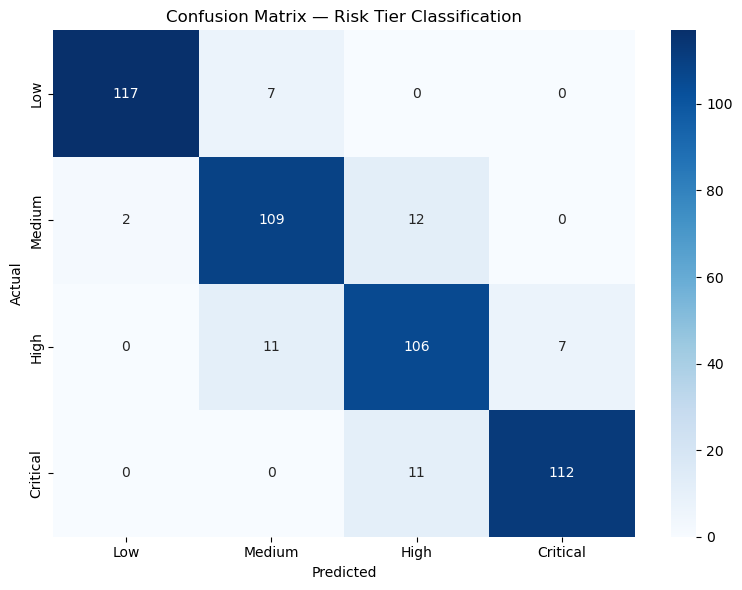

In [17]:
y_pred      = rf.predict(X_test_sc)
y_pred_prob = rf.predict_proba(X_test_sc)

# --- Aggregate metrics ---
acc           = accuracy_score(y_test, y_pred)
prec_w        = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_w         = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_w          = f1_score(y_test, y_pred, average="weighted", zero_division=0)
f1_macro      = f1_score(y_test, y_pred, average="macro", zero_division=0)
rec_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
rec_high      = rec_per_class[2]   # class 2 = High
rec_critical  = rec_per_class[3]   # class 3 = Critical

# --- ROC-AUC (One-vs-Rest) ---
y_bin   = label_binarize(y_test, classes=[0, 1, 2, 3])
roc_auc = roc_auc_score(y_bin, y_pred_prob, multi_class="ovr", average="macro")

print("=" * 45)
print(f"  Accuracy           : {acc:.3f}")
print(f"  F1 (weighted)      : {f1_w:.3f}")
print(f"  F1 (macro)         : {f1_macro:.3f}   ← equal weight per class")
print(f"  ROC-AUC (OvR macro): {roc_auc:.3f}")
print(f"  High-risk recall   : {rec_high:.3f}")
print(f"  Critical recall    : {rec_critical:.3f}  ← primary safety metric")
print("=" * 45)
print()

# Per-class breakdown
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High", "Critical"]))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High", "Critical"],
            yticklabels=["Low", "Medium", "High", "Critical"],
            ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Risk Tier Classification")
plt.tight_layout()
plt.show()

### Cross validation

In [18]:
cv_f1_w = cross_val_score(rf, scaler.fit_transform(X), y, cv=5, scoring="f1_weighted")
cv_f1_m = cross_val_score(rf, scaler.fit_transform(X), y, cv=5, scoring="f1_macro")

print(f"CV F1 (weighted): {cv_f1_w.mean():.3f} ± {cv_f1_w.std():.3f}")
print(f"CV F1 (macro)  : {cv_f1_m.mean():.3f} ± {cv_f1_m.std():.3f}   ← equal weight per class")

CV F1 (weighted): 0.805 ± 0.093
CV F1 (macro)  : 0.805 ± 0.093   ← equal weight per class


### Learning Curve
Shows whether the model benefits from more data (high bias) or is overfitting (high variance).

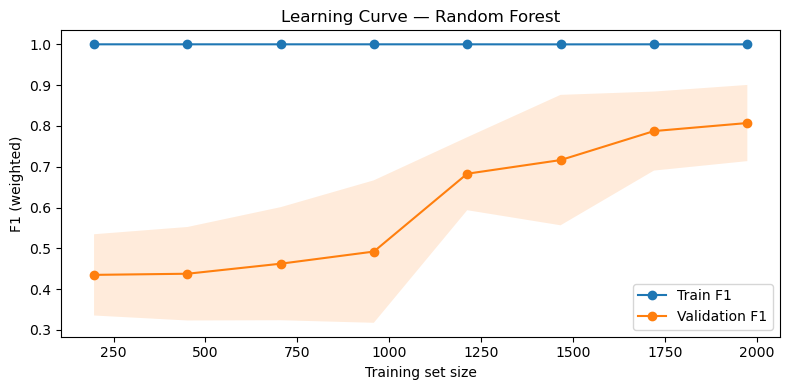

In [19]:
train_sizes, train_scores, val_scores = learning_curve(
    rf,
    scaler.fit_transform(X), y,
    cv=5,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train F1", marker="o")
plt.plot(train_sizes, val_scores.mean(axis=1),   label="Validation F1", marker="o")
plt.fill_between(train_sizes,
    train_scores.mean(1) - train_scores.std(1),
    train_scores.mean(1) + train_scores.std(1), alpha=0.15)
plt.fill_between(train_sizes,
    val_scores.mean(1) - val_scores.std(1),
    val_scores.mean(1) + val_scores.std(1), alpha=0.15)
plt.xlabel("Training set size")
plt.ylabel("F1 (weighted)")
plt.title("Learning Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Observed Issues & Potential Improvements

### Issue 1: Label–Feature Gap (Addressed)
The composite risk label blends SVI (40%) with infrastructure signals. Earlier versions excluded SVI from `X`, causing the model to predict a target it had no direct signal for (CV F1 ≈ 0.41). Adding `rpl_theme_1`–`rpl_theme_4` as features closed this gap.

**Remaining improvements:**
- Add elevation/slope data — steep terrain slows evacuation and correlates with wildfire spread.
- Add distance to historical wildfire perimeters (CAL FIRE FRAP dataset) as a proxy for ignition likelihood.

### Issue 2: Label Construction Uncertainty
The composite risk score weights (0.4 SVI / 0.3 fire distance / 0.2 road density / 0.1 hydrant density) are heuristic. Different weight choices shift which tracts are labelled High-risk.

**What would improve this:**
- Validate weights through a literature review or expert elicitation.
- Run a sensitivity analysis: vary each weight ±0.1 and compare how tract risk labels change.

### Issue 3: Class Imbalance
Even with quantile-based binning, `class_weight="balanced"` mitigates but does not eliminate imbalance effects.

**What would improve this:**
- Apply SMOTE oversampling (`imbalanced-learn`) on the training set.
- Report macro-averaged F1 alongside weighted F1 to surface per-class weaknesses (now included above).

### SHAP Explainability

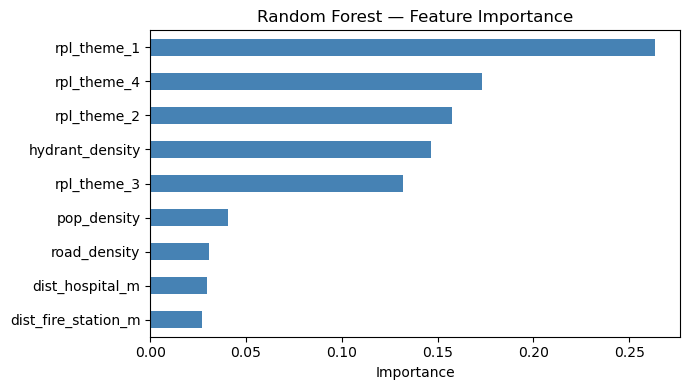

In [20]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

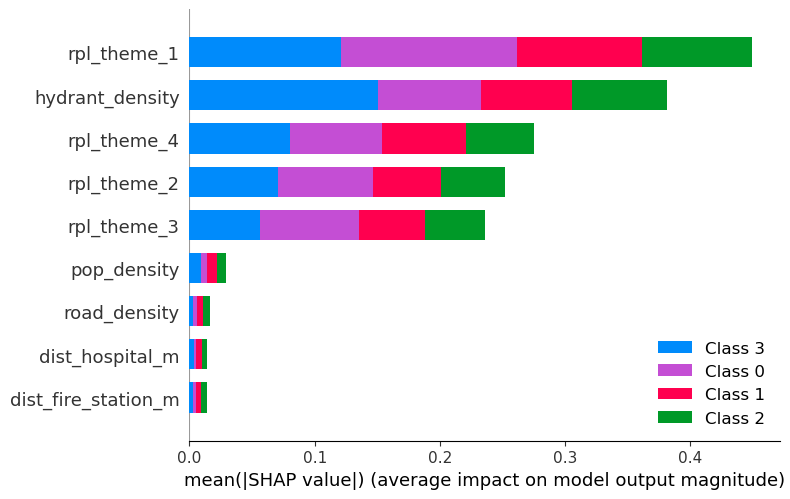

In [21]:
X_test_df = pd.DataFrame(X_test_sc, columns=FEATURES)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

# Summary plot for the Critical-risk class (index 3) — most safety-critical
critical_shap = shap_values[3] if isinstance(shap_values, list) else shap_values
shap.summary_plot(
    critical_shap,
    X_test_df,
    plot_type="bar",
    title="SHAP Feature Importance — Critical-Risk Class",
)

In [23]:
X_all_sc = scaler.transform(X)
tracts["predicted_tier"]      = rf.predict(X_all_sc)
tracts["predicted_tier_label"] = tracts["predicted_tier"].map(TIER_LABELS)

# Save enriched GeoJSON for visualization notebook
tracts.to_file(DATA_PROC / "tract_features_predicted.geojson", driver="GeoJSON")
# print("Saved tract_features_predicted.geojson")

In [24]:
joblib.dump(rf,     MODEL_OUT / "risk_classifier.pkl")
joblib.dump(scaler, MODEL_OUT / "scaler.pkl")
print("Saved risk_classifier.pkl and scaler.pkl")

Saved risk_classifier.pkl and scaler.pkl
